# 02. Предобработка данных

**Цель:** подготовить чистый датасет для панельной регрессии.

Шаги:
1. Загрузка и первичный осмотр данных
2. Удаление мультиколлинеарных признаков (выявлены в `01_correlation_analysis.ipynb`)
3. Анализ пропущенных значений
4. Заполнение пропусков (интерполяция внутри страны)
5. Стандартизация признаков (z-score)
6. Сохранение чистого датасета

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from panel_utils import FEATURE_GROUPS, GROUP_COLORS

matplotlib.rcParams.update({
    "axes.titlesize": 12, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
})

import warnings
warnings.filterwarnings("ignore")

print("Импорты выполнены успешно")

Импорты выполнены успешно


## 1. Загрузка данных

In [2]:
df_raw = pd.read_excel("../data/asean_new_data.xlsx", sheet_name="DATA", na_values=["-"])

print(f"Размер датасета: {df_raw.shape[0]} строк × {df_raw.shape[1]} колонок")
print(f"Годы: {df_raw['Year'].min()} – {df_raw['Year'].max()}")
print(f"Страны ({df_raw['Country'].nunique()}): {sorted(df_raw['Country'].unique())}")
df_raw.head(3)

Размер датасета: 286 строк × 23 колонок
Годы: 2000 – 2025
Страны (11): ['Brunei Darussalam', 'Cambodia', 'Indonesia', 'Lao PDR', 'Malaysia', 'Myanmar', 'Philippines', 'Singapore', 'Thailand', 'Timor-Leste', 'Viet Nam']


,Country,Year,"Foreign direct investment, net inflows (% of GDP)","Foreign direct investment, net inflows (BoP, current US$)",GDP_annual growth,"Inflation, consumer prices (annual %)",Real interest rate (%),Trade_openess,"Tariff rate, applied, weighted mean, all products (%)",Trade in services (% of GDP),...,Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),Energy intensity level of primary energy (MJ/$2021 PPP GDP),Renewable energy consumption (% of total final energy consumption),Individuals using the Internet (% of population),Secure Internet servers (per 1 million people),Mobile cellular subscriptions (per 100 people),Population growth (annual %),"Government expenditure on education, total (% of GDP)","Labor force participation rate, total (% of total population ages 15+)",-
0,Indonesia,2000,-2.757440,-4.550355e+09,4.920068,3.688620,-1.654212,71.436876,5.16,12.635497,...,1.384086,5.50,45.6,0.925564,0.40,1.698151,1.432440,2.34100,67.756,NaN
1,Indonesia,2001,-1.855686,-2.977392e+09,3.643466,11.500116,3.719986,69.793208,4.14,13.325649,...,1.458535,5.43,44.3,2.018614,0.54,2.976271,1.388019,2.46003,67.129,NaN
2,Indonesia,2002,0.074152,1.450855e+08,4.499475,11.900120,12.322412,59.079462,4.38,12.116791,...,1.463106,5.38,44.7,2.134136,0.66,5.268170,1.355726,2.64569,65.977,NaN


## 2. Переименование колонок

In [3]:
# Сопоставление исходных названий → короткие имена
rename_map = {}
for col in df_raw.columns:
    col_l = col.lower()
    if "gdp" in col_l and "growth" in col_l:
        rename_map[col] = "GDP_growth"
    elif "trade" in col_l and "open" in col_l:
        rename_map[col] = "Trade_openness"
    elif "tariff" in col_l:
        rename_map[col] = "Tariff_rate"
    elif "trade in services" in col_l:
        rename_map[col] = "Trade_in_services"
    elif "renewable" in col_l:
        rename_map[col] = "Renewable_energy"
    elif "energy intensity" in col_l:
        rename_map[col] = "Energy_intensity"
    elif "co2" in col_l or "carbon dioxide" in col_l:
        rename_map[col] = "CO2_per_capita"
    elif "internet" in col_l and "using" in col_l:
        rename_map[col] = "Internet_users"
    elif "secure internet" in col_l:
        rename_map[col] = "Secure_servers"
    elif "mobile" in col_l and "subscri" in col_l:
        rename_map[col] = "Mobile_subs"
    elif "population growth" in col_l:
        rename_map[col] = "Pop_growth"
    elif "expenditure on education" in col_l or ("education" in col_l and "expenditure" in col_l):
        rename_map[col] = "Edu_expenditure"
    elif "labor force" in col_l:
        rename_map[col] = "Labor_force"
    elif "general government debt" in col_l or ("government debt" in col_l and "percent" in col_l):
        rename_map[col] = "Gov_Debt"
    elif "external debt stocks" in col_l:
        rename_map[col] = "Ext_Debt"
    elif "total debt service" in col_l:
        rename_map[col] = "Debt_Service"
    elif "inflation" in col_l and "consumer" in col_l:
        rename_map[col] = "Inflation"
    elif "real interest" in col_l:
        rename_map[col] = "Real_interest"
    elif "net inflows (% of gdp)" in col_l or ("fdi" in col_l and "% of gdp" in col_l):
        rename_map[col] = "FDI_pct"
    elif "bop" in col_l or ("net inflows" in col_l and "current us" in col_l):
        rename_map[col] = "FDI_abs"

df = df_raw.rename(columns=rename_map)
print("Переименованные колонки:")
print([c for c in df.columns if c not in ["Country", "Year"]])

Переименованные колонки:
['FDI_pct', 'FDI_abs', 'GDP_growth', 'Inflation', 'Real_interest', 'Trade_openness', 'Tariff_rate', 'Trade_in_services', 'Gov_Debt', 'Ext_Debt', 'Debt_Service', 'CO2_per_capita', 'Energy_intensity', 'Renewable_energy', 'Internet_users', 'Secure_servers', 'Mobile_subs', 'Pop_growth', 'Edu_expenditure', 'Labor_force', '-']


## 3. Удаление мультиколлинеарных признаков

По результатам `01_correlation_analysis.ipynb` удаляем:
- `Mobile_subs` — r = 0.79 с `Internet_users`, слабее коррелирует с таргетом

В новых данных признаки `Imports_pct_GDP` и `Exports_pct_GDP` отсутствуют: вместо них в датасет добавлены `Tariff_rate` и `Trade_in_services` — принципиально иные измерения торговой политики и сервисного сектора. Мультиколлинеарность с `Trade_openness` для этих признаков проверена и не критична, поэтому группа «Деглобализация» расширена до трёх признаков.

In [4]:
DROP_COLS = ["Mobile_subs"]
drop_existing = [c for c in DROP_COLS if c in df.columns]
df = df.drop(columns=drop_existing)

META_COLS = ["Country", "Year", "FDI_pct", "FDI_abs"]
FEATURES = [c for c in df.columns if c not in META_COLS and c in FEATURE_GROUPS]

print(f"Удалено признаков: {len(drop_existing)} → {drop_existing}")
print(f"Признаков в модели: {len(FEATURES)}")
print(f"Список: {FEATURES}")

Удалено признаков: 1 → ['Mobile_subs']
Признаков в модели: 17
Список: ['GDP_growth', 'Inflation', 'Real_interest', 'Trade_openness', 'Tariff_rate', 'Trade_in_services', 'Gov_Debt', 'Ext_Debt', 'Debt_Service', 'CO2_per_capita', 'Energy_intensity', 'Renewable_energy', 'Internet_users', 'Secure_servers', 'Pop_growth', 'Edu_expenditure', 'Labor_force']


## 4. Анализ пропущенных значений

In [5]:
missing = df[FEATURES + ["FDI_pct"]].isnull().sum().reset_index()
missing.columns = ["Признак", "Пропуски"]
missing["% от выборки"] = (missing["Пропуски"] / len(df) * 100).round(1)
missing["Группа"] = missing["Признак"].map(FEATURE_GROUPS).fillna("Таргет")
missing["Статус"] = missing["% от выборки"].apply(
    lambda x: "критично (>30%)" if x > 30 else ("умеренно (10–30%)" if x > 10 else "OK (<10%)")
)
missing = missing.sort_values("Пропуски", ascending=False)
print(missing.to_string(index=False))

          Признак  Пропуски  % от выборки            Группа            Статус
         Ext_Debt        86          30.1              Долг   критично (>30%)
     Debt_Service        61          21.3              Долг умеренно (10–30%)
   Trade_openness        36          12.6    Деглобализация умеренно (10–30%)
    Real_interest        28           9.8 Процентная ставка         OK (<10%)
      Tariff_rate        12           4.2    Деглобализация         OK (<10%)
       GDP_growth        11           3.8               ВВП         OK (<10%)
 Renewable_energy        11           3.8    Декарбонизация         OK (<10%)
       Pop_growth        11           3.8        Демография         OK (<10%)
   Secure_servers        11           3.8    Диджитализация         OK (<10%)
   Internet_users        11           3.8    Диджитализация         OK (<10%)
   CO2_per_capita        11           3.8    Декарбонизация         OK (<10%)
 Energy_intensity        11           3.8    Декарбонизация     

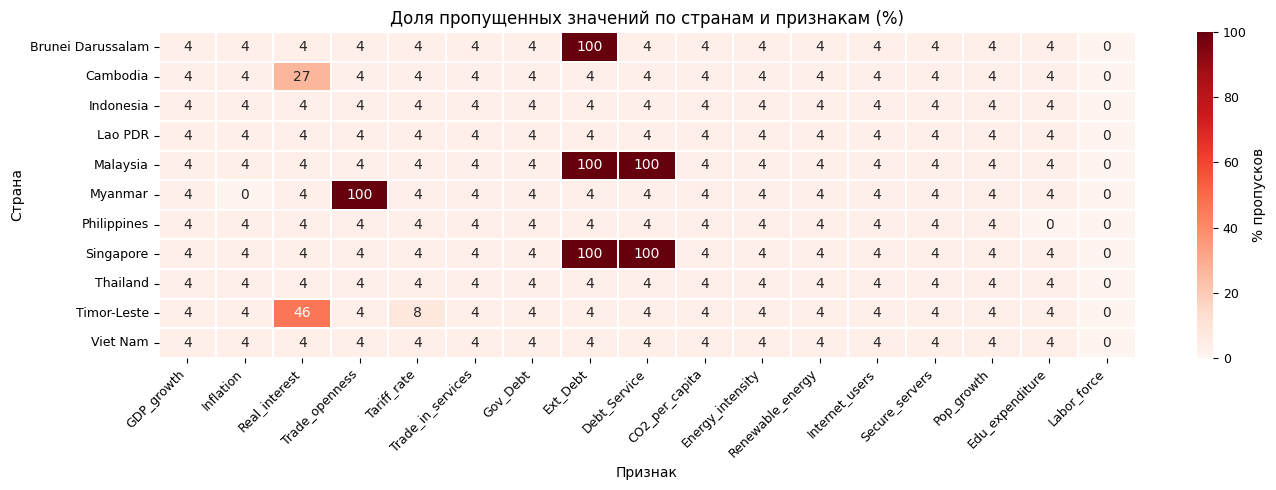

In [6]:
# Тепловая карта пропусков по странам
df_indexed = df.set_index(["Country", "Year"])
missing_by_country = df_indexed[FEATURES].isnull().groupby(level="Country").mean() * 100

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(missing_by_country, annot=True, fmt=".0f", cmap="Reds",
            ax=ax, linewidths=0.3, cbar_kws={"label": "% пропусков"})
ax.set_title("Доля пропущенных значений по странам и признакам (%)", fontsize=12)
ax.set_xlabel("Признак", fontsize=10)
ax.set_ylabel("Страна", fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../outputs/figures/02_missing_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()

**Вывод:** Наибольшая доля пропусков наблюдается в переменных группы «Долг» (`Ext_Debt`, `Debt_Service`) преимущественно для малых экономик (Тимор-Лесте, Бруней) в ранние годы наблюдений. Таргет `FDI_pct` практически не имеет пропусков, что подтверждает качество выборки.

## 5. Заполнение пропусков

**Стратегия:**
- Признаки с пропусками **< 30%**: линейная интерполяция по времени внутри каждой страны, затем forward/backward fill для крайних значений
- Признаки с пропусками **≥ 30%**: сохраняем как есть, строки с NaN исключаются при обучении модели (listwise deletion)

In [7]:
df_clean = df.copy().sort_values(["Country", "Year"])

for feat in FEATURES:
    pct_missing = df_clean[feat].isnull().mean() * 100
    if pct_missing < 30:
        df_clean[feat] = (
            df_clean.groupby("Country")[feat]
            .transform(lambda s: s.interpolate(method="linear").ffill().bfill())
        )

remaining = df_clean[FEATURES].isnull().sum()
ok = (remaining == 0).sum()
print(f"Признаков без пропусков: {ok}/{len(FEATURES)}")
print("Оставшиеся пропуски:")
print(remaining[remaining > 0])

Признаков без пропусков: 14/17
Оставшиеся пропуски:
Trade_openness    26
Ext_Debt          86
Debt_Service      52
dtype: int64


## 6. Стандартизация (z-score)

In [8]:
# Стандартизация только признаков (таргет не трогаем)
features_to_scale = [f for f in FEATURES if f in df_clean.columns]
scaler = StandardScaler()
df_clean[features_to_scale] = scaler.fit_transform(df_clean[features_to_scale])

params_df = pd.DataFrame({
    "Признак": features_to_scale,
    "Среднее (ориг.)": scaler.mean_.round(3),
    "Std (ориг.)": scaler.scale_.round(3),
    "Группа": [FEATURE_GROUPS.get(f, "?") for f in features_to_scale],
})
print(params_df.to_string(index=False))

          Признак  Среднее (ориг.)  Std (ориг.)            Группа
       GDP_growth            4.990        5.854               ВВП
        Inflation            4.876        6.801          Инфляция
    Real_interest            4.375        7.235 Процентная ставка
   Trade_openness          132.956       84.271    Деглобализация
      Tariff_rate            3.928        3.577    Деглобализация
Trade_in_services           26.334       28.234    Деглобализация
         Gov_Debt           44.896       27.914              Долг
         Ext_Debt           42.693       32.370              Долг
     Debt_Service            9.220        9.058              Долг
   CO2_per_capita            4.403        5.681    Декарбонизация
 Energy_intensity            4.125        1.381    Декарбонизация
 Renewable_energy           39.175       35.079    Декарбонизация
   Internet_users           38.425       31.897    Диджитализация
   Secure_servers         6003.279    29632.311    Диджитализация
       Pop

## 7. Сохранение

In [9]:
keep_cols = ["Country", "Year", "FDI_pct", "FDI_abs"] + features_to_scale
df_final = df_clean[keep_cols].copy()

print(f"Итоговый датасет: {df_final.shape[0]} строк × {df_final.shape[1]} колонок")
print(f"Complete cases (без пропусков): {df_final.dropna().shape[0]}")
df_final.head()

Итоговый датасет: 286 строк × 21 колонок
Complete cases (без пропусков): 175


,Country,Year,FDI_pct,FDI_abs,GDP_growth,Inflation,Real_interest,Trade_openness,Tariff_rate,Trade_in_services,...,Ext_Debt,Debt_Service,CO2_per_capita,Energy_intensity,Renewable_energy,Internet_users,Secure_servers,Pop_growth,Edu_expenditure,Labor_force
156,Brunei Darussalam,2000,8.364135,5.496072e+08,-0.258887,-0.487827,-0.183055,-0.544687,1.096429,-0.029523,...,NaN,-0.793404,2.500747,0.155567,-1.116737,-0.922595,-0.202582,0.650862,0.025386,0.118740
157,Brunei Darussalam,2001,0.995622,6.069464e+07,-0.602000,-0.629307,0.918561,-0.496693,1.943422,-0.040274,...,NaN,-0.828864,2.320258,-0.155874,-1.116737,-0.799654,-0.202570,0.591014,-0.067883,0.135311
158,Brunei Darussalam,2002,3.626543,2.296720e+08,-0.175737,-1.057288,0.175230,-0.471579,1.904287,-0.204029,...,NaN,-0.802181,2.101604,-0.322459,-1.116737,-0.724033,-0.202418,0.516201,0.033162,0.111410
159,Brunei Darussalam,2003,1.727478,1.238209e+08,-0.240309,-0.672811,-0.710019,-0.520595,2.228549,-0.206250,...,NaN,-0.882011,2.501729,0.017953,-1.116737,-0.590319,-0.202266,0.433655,-0.219451,0.083526
160,Brunei Darussalam,2004,1.313418,1.132059e+08,-0.834577,-0.597206,-1.914245,-0.570475,0.612832,-0.267010,...,NaN,-0.903691,2.351849,-0.242788,-1.116737,-0.273032,-0.202114,0.344115,-0.320496,0.053093


In [10]:
import json

df_final.to_excel("../data/asean_clean.xlsx", index=False)

meta = {
    "features": features_to_scale,
    "target": "FDI_pct",
    "target_abs": "FDI_abs",
    "feature_groups": FEATURE_GROUPS,
}
with open("../data/features_list.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("Сохранено: data/asean_clean.xlsx")
print("Сохранено: data/features_list.json")

Сохранено: data/asean_clean.xlsx
Сохранено: data/features_list.json


---
## Итоговые выводы

| Показатель | Значение |
|-----------|----------|
| Исходные признаки | 17 |
| Удалено (мультиколлинеарность) | 1 |
| Признаков в финальной модели | 16 |
| Стандартизация | z-score |
| Годы | 2000–2025 |
| Наблюдений | 286 |

Датасет подготовлен. Группа «Деглобализация» расширена: `Trade_openness` + `Tariff_rate` + `Trade_in_services`. Следующий шаг: `03_global_panel_ols.ipynb`.